# 🏢 İnsan Kaynakları Analitiği: Çalışan Ayrılma Tahmini

Bu notebook, bir şirketteki çalışanların hangi faktörlere bağlı olarak işten ayrılma eğiliminde olduğunu analiz eder.

## 📋 İçindekiler
1. Veri Yükleme ve Keşifsel Analiz (EDA)
2. Veri Görselleştirme
3. Personel Devir Hızı Hesaplama
4. Makine Öğrenmesi Modeli (Logistic Regression)
5. Sonuçlar ve Öneriler

---
## 1. Kütüphanelerin Yüklenmesi ve Veri Hazırlığı

In [1]:
# Gerekli kütüphaneleri yükle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

# Grafik stilini ayarla
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("✅ Kütüphaneler başarıyla yüklendi!")

Matplotlib is building the font cache; this may take a moment.


✅ Kütüphaneler başarıyla yüklendi!


### 1.1 Veri Setini Yükleme

In [2]:
# Veri setini yükle
df = pd.read_csv('../data/hr_employee_attrition.csv')

print(f"📊 Veri Seti Boyutu: {df.shape[0]} satır, {df.shape[1]} sütun")
print("\n" + "="*60)
print("\n🔍 İlk 5 Satır:")
df.head()

📊 Veri Seti Boyutu: 1470 satır, 29 sütun


🔍 İlk 5 Satır:


,EmployeeID,Age,Gender,MaritalStatus,Education,EducationField,Department,JobRole,JobLevel,YearsAtCompany,...,DistanceFromHome,BusinessTravel,OverTime,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating,Attrition
0,1,56,Female,Married,3,Human Resources,Research & Development,Human Resources,3,18,...,2,Travel_Rarely,No,2,3,4,3,3,3,No
1,2,46,Male,Single,1,Technical Degree,Research & Development,Sales Representative,1,10,...,13,Travel_Rarely,No,2,4,4,1,4,4,No
2,3,32,Male,Single,5,Medical,Research & Development,Research Scientist,2,8,...,25,Travel_Rarely,No,3,2,3,4,3,3,Yes
3,4,25,Male,Single,3,Human Resources,Research & Development,Sales Representative,5,13,...,16,Travel_Frequently,No,1,4,3,3,3,3,No
4,5,38,Male,Married,2,Medical,Sales,Sales Representative,1,8,...,8,Travel_Rarely,No,4,2,1,3,1,3,No


### 1.2 Veri Seti Hakkında Genel Bilgi

In [3]:
# Veri seti bilgisi
print("📋 Veri Seti Bilgisi:")
print("="*60)
df.info()

📋 Veri Seti Bilgisi:
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   EmployeeID                1470 non-null   int64
 1   Age                       1470 non-null   int64
 2   Gender                    1470 non-null   str  
 3   MaritalStatus             1470 non-null   str  
 4   Education                 1470 non-null   int64
 5   EducationField            1470 non-null   str  
 6   Department                1470 non-null   str  
 7   JobRole                   1470 non-null   str  
 8   JobLevel                  1470 non-null   int64
 9   YearsAtCompany            1470 non-null   int64
 10  YearsInCurrentRole        1470 non-null   int64
 11  YearsSinceLastPromotion   1470 non-null   int64
 12  YearsWithCurrManager      1470 non-null   int64
 13  TotalWorkingYears         1470 non-null   int64
 14  NumCompaniesWorked        1470

In [4]:
# İstatistiksel özet
print("📈 Sayısal Değişkenlerin İstatistiksel Özeti:")
df.describe().round(2)

📈 Sayısal Değişkenlerin İstatistiksel Özeti:


,EmployeeID,Age,Education,JobLevel,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TotalWorkingYears,NumCompaniesWorked,...,MonthlyIncome,PercentSalaryHike,StockOptionLevel,DistanceFromHome,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating
count,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,...,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,735.50,38.81,3.05,3.11,12.93,6.31,5.29,6.09,19.33,4.57,...,9186.27,17.63,1.53,15.06,2.49,2.51,2.53,2.49,2.45,3.11
std,424.50,12.13,1.40,1.43,9.16,4.77,4.04,4.56,11.48,2.91,...,3126.03,4.14,1.11,8.30,1.10,1.13,1.10,1.11,1.13,0.31
min,1.00,18.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,...,3026.00,11.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,3.00
25%,368.25,28.00,2.00,2.00,5.00,2.00,2.00,2.00,10.00,2.00,...,6622.50,14.00,1.00,8.00,2.00,1.00,2.00,2.00,1.00,3.00
50%,735.50,40.00,3.00,3.00,12.00,6.00,5.00,5.00,19.00,5.00,...,9338.00,17.00,2.00,15.00,2.00,3.00,3.00,3.00,2.00,3.00
75%,1102.75,50.00,4.00,4.00,19.00,10.00,8.00,9.00,30.00,7.00,...,11770.50,21.00,3.00,22.00,3.00,4.00,3.00,3.00,3.00,3.00
max,1470.00,59.00,5.00,5.00,39.00,17.00,14.00,16.00,39.00,9.00,...,14987.00,24.00,3.00,29.00,4.00,4.00,4.00,4.00,4.00,4.00


In [5]:
# Eksik değer kontrolü
print("❓ Eksik Değer Kontrolü:")
print("="*60)
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✅ Eksik değer bulunmamaktadır!")
else:
    print(missing[missing > 0])

❓ Eksik Değer Kontrolü:
✅ Eksik değer bulunmamaktadır!


In [6]:
# Hedef değişken dağılımı
print("🎯 Hedef Değişken (Attrition) Dağılımı:")
print("="*60)
attrition_counts = df['Attrition'].value_counts()
attrition_pct = df['Attrition'].value_counts(normalize=True) * 100

print(f"Kalan Çalışanlar (No): {attrition_counts['No']} ({attrition_pct['No']:.1f}%)")
print(f"Ayrılan Çalışanlar (Yes): {attrition_counts['Yes']} ({attrition_pct['Yes']:.1f}%)")

🎯 Hedef Değişken (Attrition) Dağılımı:
Kalan Çalışanlar (No): 660 (44.9%)
Ayrılan Çalışanlar (Yes): 810 (55.1%)


---
## 2. Veri Görselleştirme 📊

### 2.1 Ayrılma Dağılımı

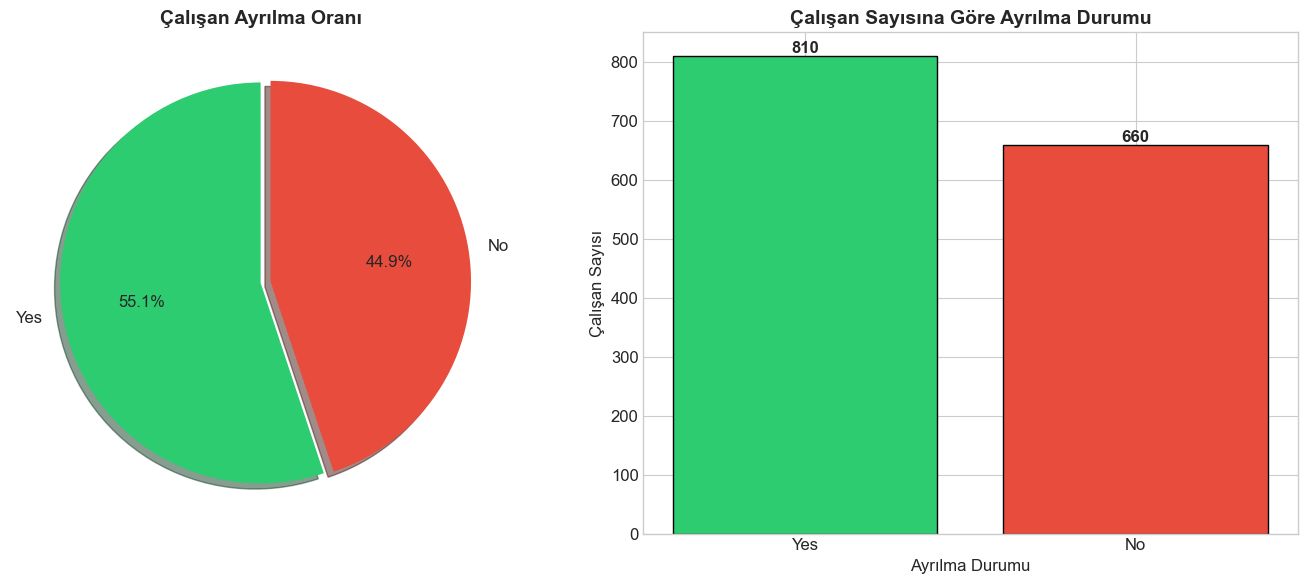

📁 Grafik kaydedildi: outputs/01_attrition_distribution.png


In [7]:
# Ayrılma dağılımı - Pasta ve Bar grafik
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pasta grafik
colors = ['#2ecc71', '#e74c3c']
explode = (0, 0.05)
attrition_counts.plot(kind='pie', ax=axes[0], colors=colors, explode=explode,
                      autopct='%1.1f%%', shadow=True, startangle=90)
axes[0].set_title('Çalışan Ayrılma Oranı', fontsize=14, fontweight='bold')
axes[0].set_ylabel('')

# Bar grafik
bars = axes[1].bar(attrition_counts.index, attrition_counts.values, color=colors, edgecolor='black')
axes[1].set_title('Çalışan Sayısına Göre Ayrılma Durumu', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Ayrılma Durumu')
axes[1].set_ylabel('Çalışan Sayısı')

# Bar üzerine değer yazma
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/01_attrition_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("📁 Grafik kaydedildi: outputs/01_attrition_distribution.png")

### 2.2 Departman Bazlı Ayrılma Analizi

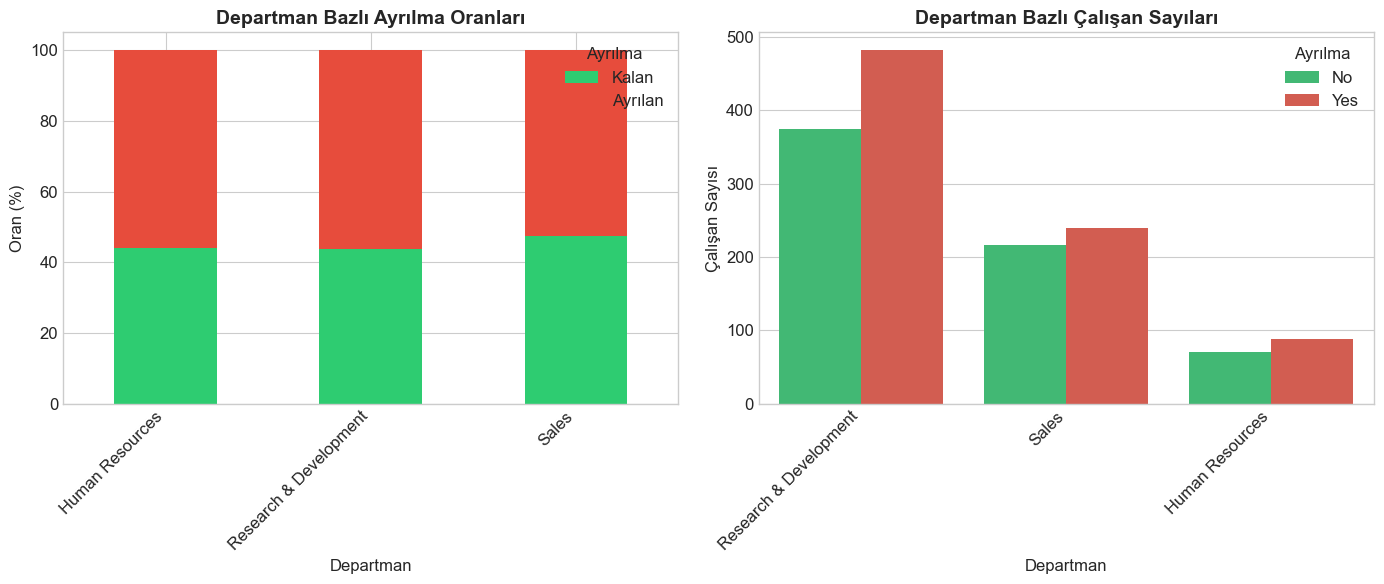

📁 Grafik kaydedildi: outputs/02_department_analysis.png


In [8]:
# Departman bazlı ayrılma oranları
dept_attrition = df.groupby('Department')['Attrition'].value_counts(normalize=True).unstack() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Stacked bar chart
dept_attrition.plot(kind='bar', stacked=True, ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Departman Bazlı Ayrılma Oranları', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Departman')
axes[0].set_ylabel('Oran (%)')
axes[0].legend(title='Ayrılma', labels=['Kalan', 'Ayrılan'])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# Count plot
sns.countplot(data=df, x='Department', hue='Attrition', ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Departman Bazlı Çalışan Sayıları', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Departman')
axes[1].set_ylabel('Çalışan Sayısı')
axes[1].legend(title='Ayrılma')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('../outputs/02_department_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("📁 Grafik kaydedildi: outputs/02_department_analysis.png")

### 2.3 Maaş ve Ayrılma İlişkisi

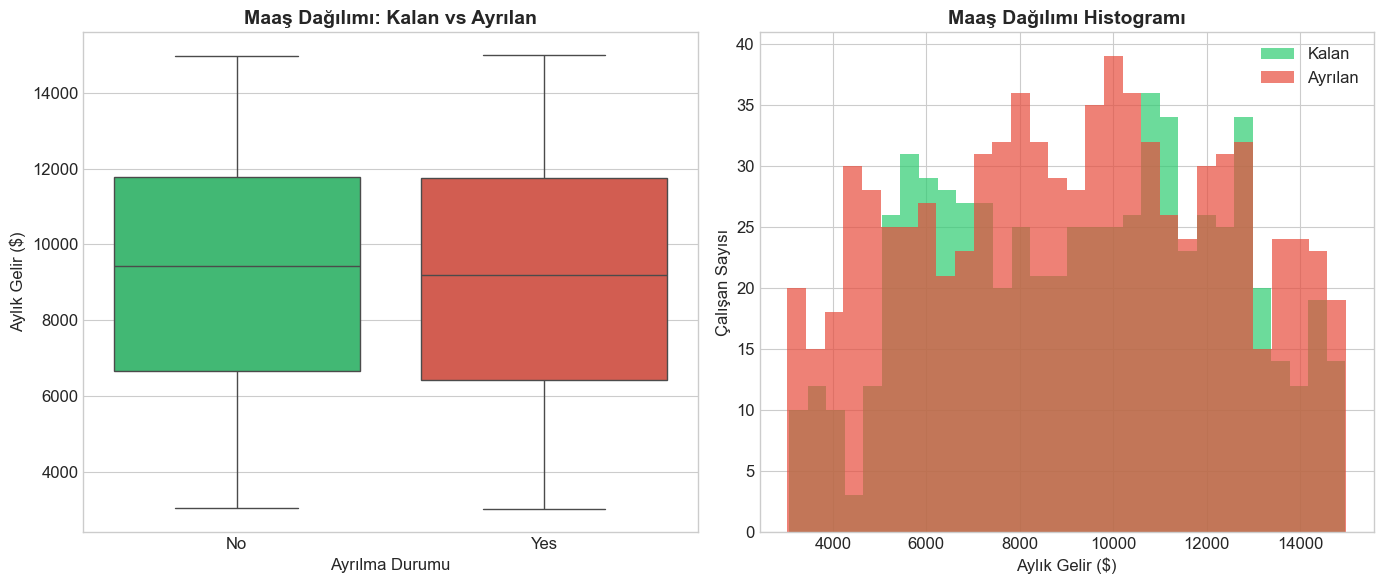

📁 Grafik kaydedildi: outputs/03_salary_analysis.png


In [9]:
# Maaş dağılımı ve ayrılma ilişkisi
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box plot
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Maaş Dağılımı: Kalan vs Ayrılan', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Ayrılma Durumu')
axes[0].set_ylabel('Aylık Gelir ($)')

# Histogram
df[df['Attrition'] == 'No']['MonthlyIncome'].hist(ax=axes[1], bins=30, alpha=0.7, 
                                                   label='Kalan', color='#2ecc71')
df[df['Attrition'] == 'Yes']['MonthlyIncome'].hist(ax=axes[1], bins=30, alpha=0.7, 
                                                    label='Ayrılan', color='#e74c3c')
axes[1].set_title('Maaş Dağılımı Histogramı', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Aylık Gelir ($)')
axes[1].set_ylabel('Çalışan Sayısı')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/03_salary_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("📁 Grafik kaydedildi: outputs/03_salary_analysis.png")

### 2.4 Memnuniyet Skorları Analizi

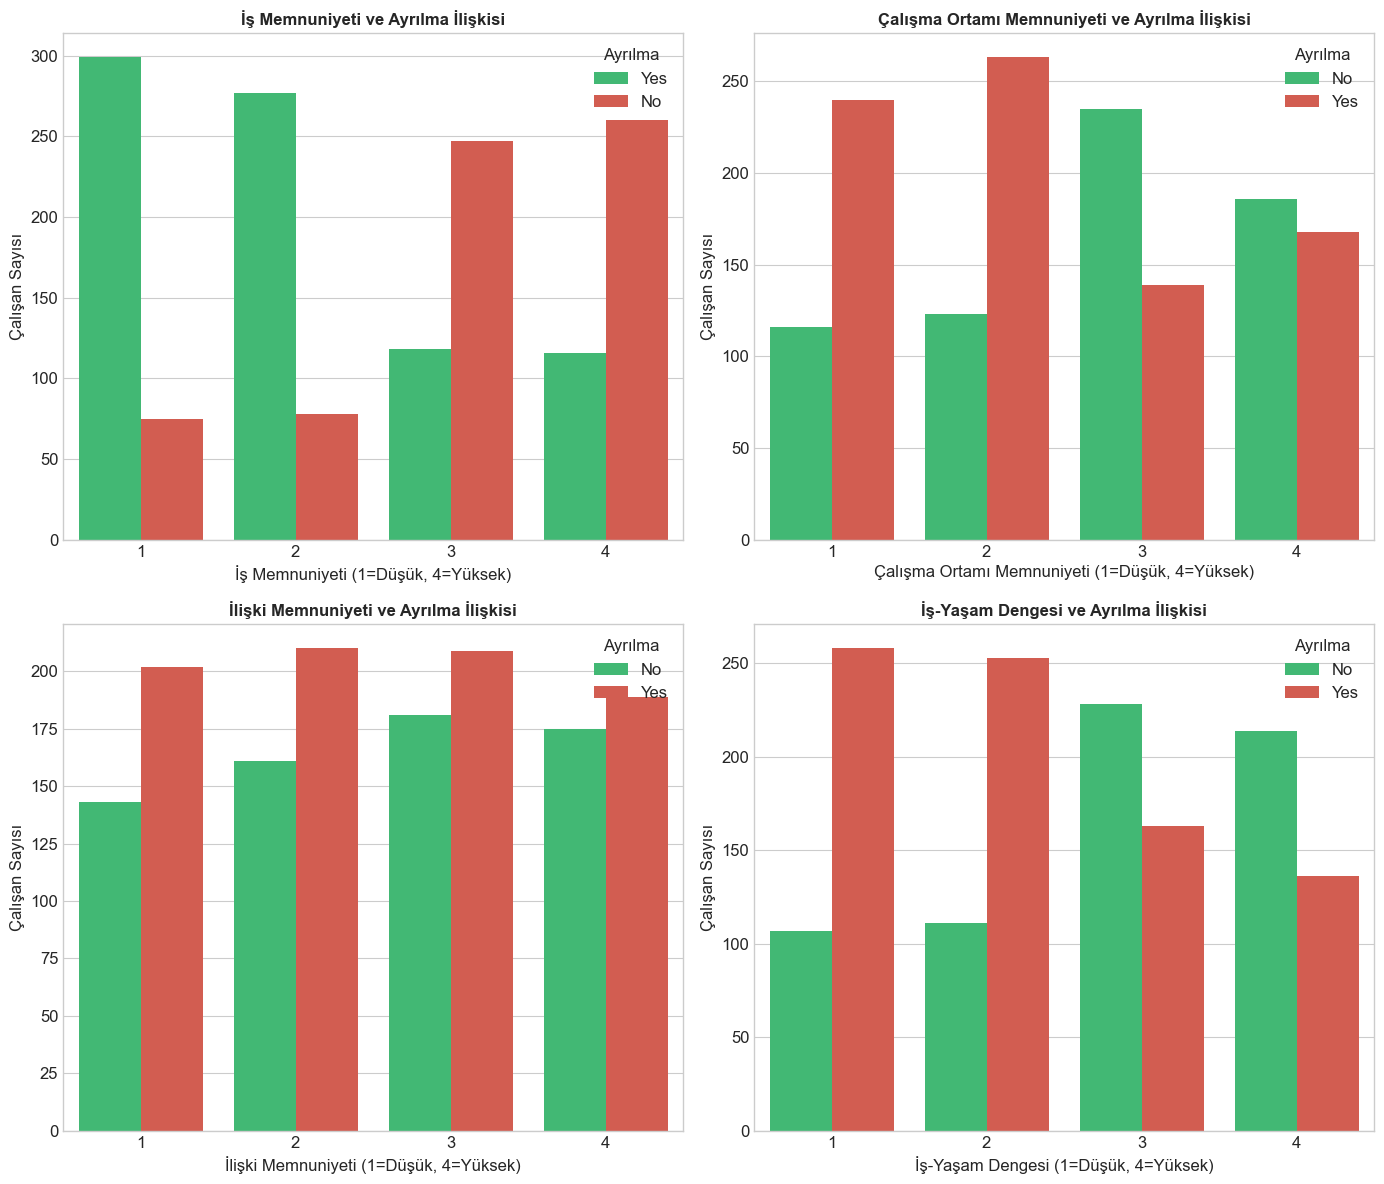

📁 Grafik kaydedildi: outputs/04_satisfaction_analysis.png


In [10]:
# Memnuniyet değişkenleri
satisfaction_vars = ['JobSatisfaction', 'EnvironmentSatisfaction', 
                     'RelationshipSatisfaction', 'WorkLifeBalance']

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

titles = ['İş Memnuniyeti', 'Çalışma Ortamı Memnuniyeti', 
          'İlişki Memnuniyeti', 'İş-Yaşam Dengesi']

for i, (var, title) in enumerate(zip(satisfaction_vars, titles)):
    # Ayrılma durumuna göre ortalama hesapla
    attrition_means = df.groupby(['Attrition', var]).size().unstack(fill_value=0)
    
    sns.countplot(data=df, x=var, hue='Attrition', ax=axes[i], palette=['#2ecc71', '#e74c3c'])
    axes[i].set_title(f'{title} ve Ayrılma İlişkisi', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(f'{title} (1=Düşük, 4=Yüksek)')
    axes[i].set_ylabel('Çalışan Sayısı')
    axes[i].legend(title='Ayrılma')

plt.tight_layout()
plt.savefig('../outputs/04_satisfaction_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("📁 Grafik kaydedildi: outputs/04_satisfaction_analysis.png")

### 2.5 Yaş ve Çalışma Süresi Analizi

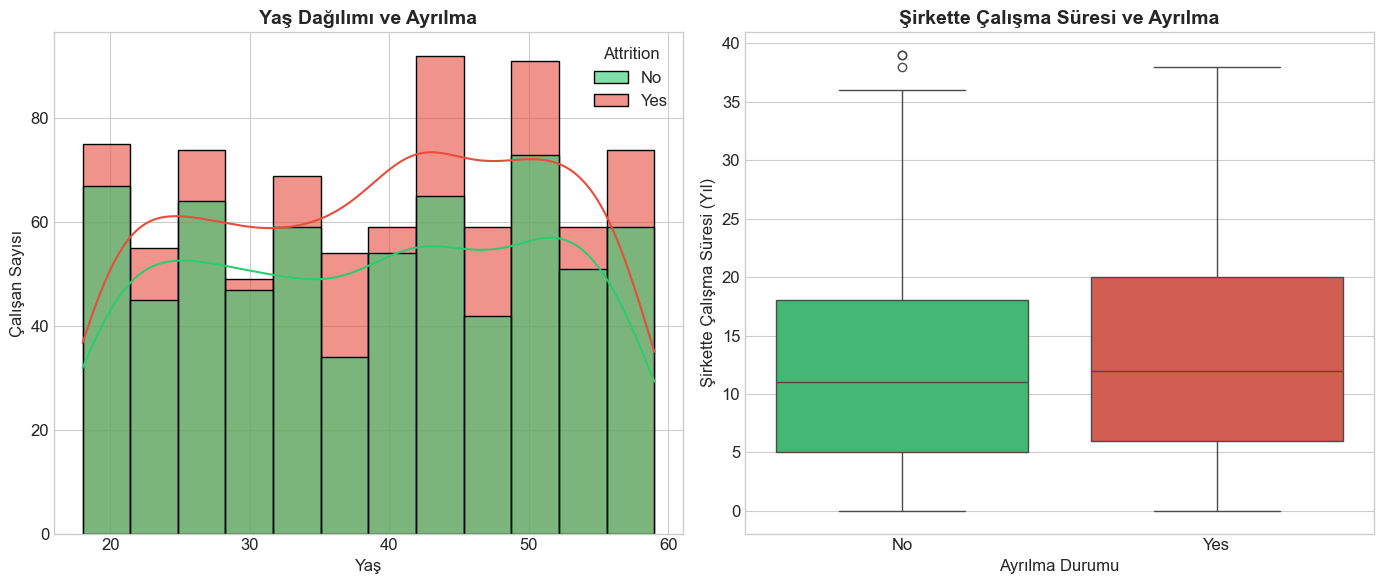

📁 Grafik kaydedildi: outputs/05_age_tenure_analysis.png


In [11]:
# Yaş ve çalışma süresi
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Yaş dağılımı
sns.histplot(data=df, x='Age', hue='Attrition', kde=True, ax=axes[0], 
             palette=['#2ecc71', '#e74c3c'], alpha=0.6)
axes[0].set_title('Yaş Dağılımı ve Ayrılma', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Yaş')
axes[0].set_ylabel('Çalışan Sayısı')

# Şirkette çalışma süresi
sns.boxplot(data=df, x='Attrition', y='YearsAtCompany', ax=axes[1], 
            palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Şirkette Çalışma Süresi ve Ayrılma', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Ayrılma Durumu')
axes[1].set_ylabel('Şirkette Çalışma Süresi (Yıl)')

plt.tight_layout()
plt.savefig('../outputs/05_age_tenure_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("📁 Grafik kaydedildi: outputs/05_age_tenure_analysis.png")

### 2.6 Fazla Mesai ve Ayrılma İlişkisi

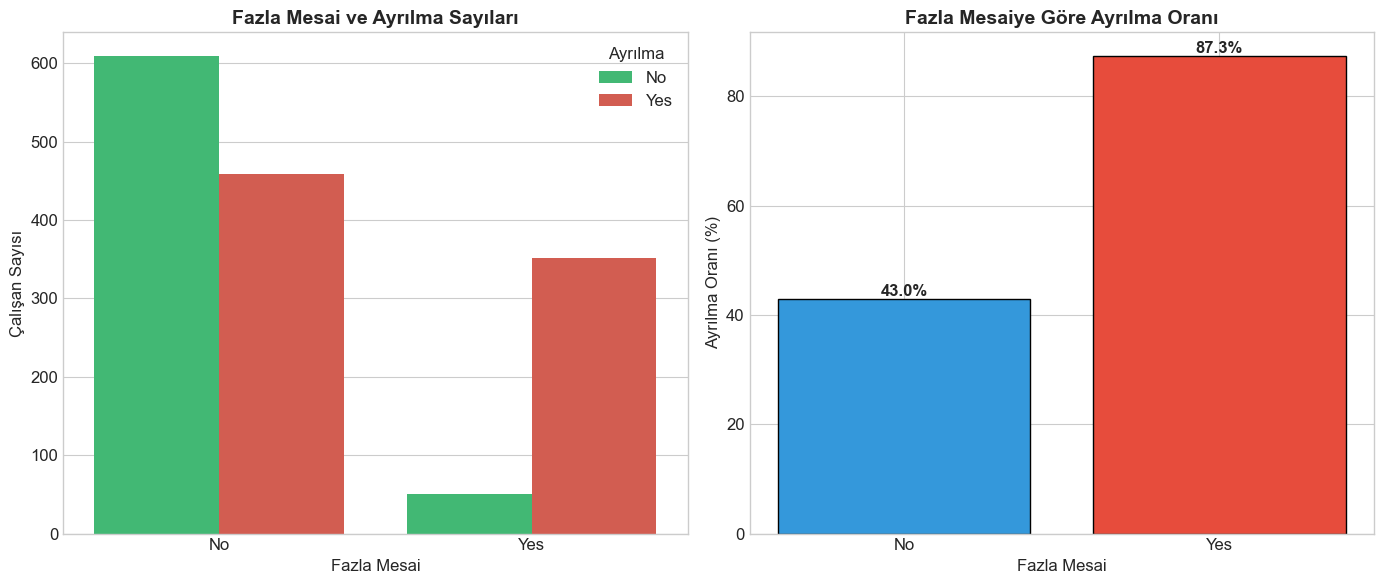

📁 Grafik kaydedildi: outputs/06_overtime_analysis.png


In [12]:
# Fazla mesai analizi
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Count plot
sns.countplot(data=df, x='OverTime', hue='Attrition', ax=axes[0], 
              palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Fazla Mesai ve Ayrılma Sayıları', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Fazla Mesai')
axes[0].set_ylabel('Çalışan Sayısı')
axes[0].legend(title='Ayrılma')

# Oran grafiği
overtime_attrition = df.groupby('OverTime')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
)
bars = axes[1].bar(overtime_attrition.index, overtime_attrition.values, 
                   color=['#3498db', '#e74c3c'], edgecolor='black')
axes[1].set_title('Fazla Mesaiye Göre Ayrılma Oranı', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Fazla Mesai')
axes[1].set_ylabel('Ayrılma Oranı (%)')

for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/06_overtime_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("📁 Grafik kaydedildi: outputs/06_overtime_analysis.png")

### 2.7 Korelasyon Matrisi

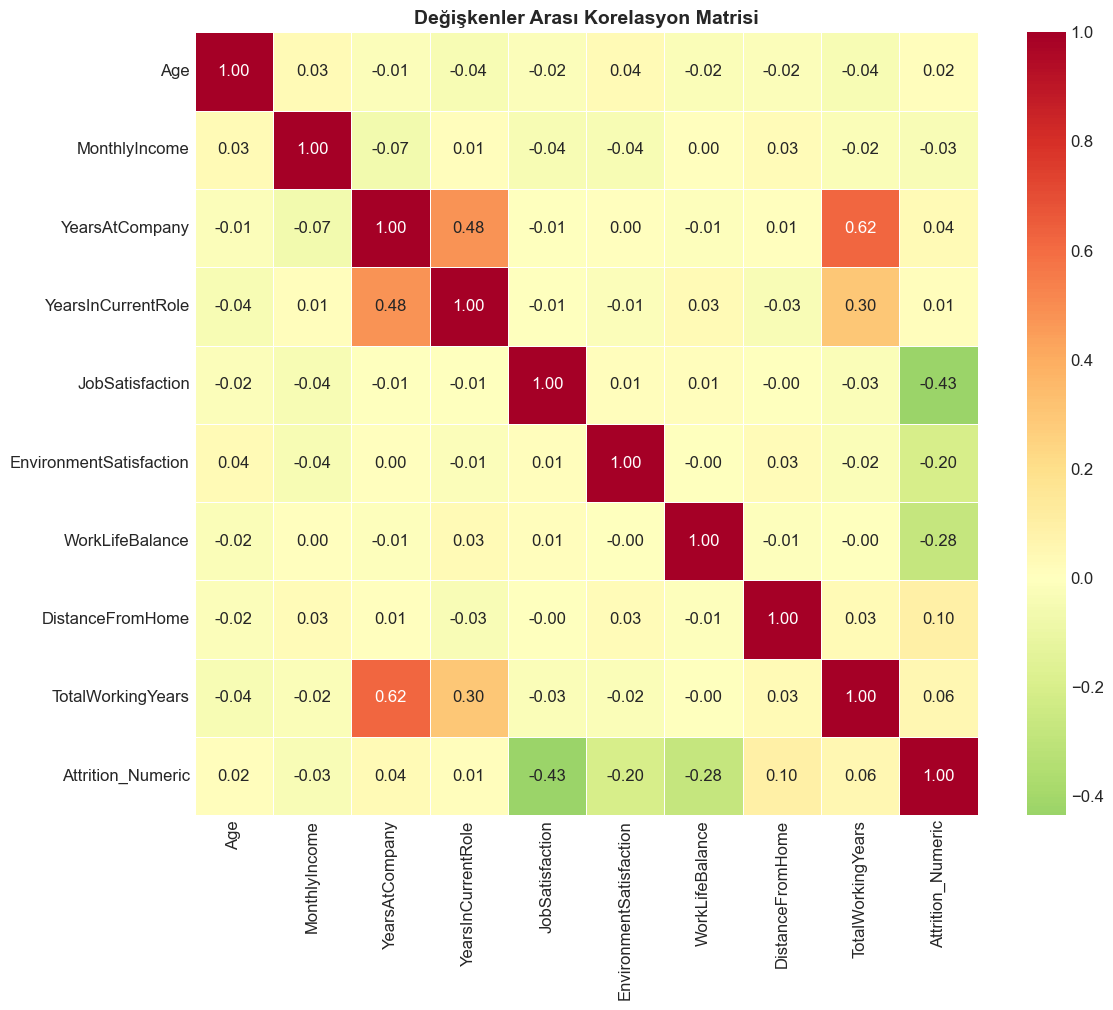

📁 Grafik kaydedildi: outputs/07_correlation_matrix.png


In [13]:
# Sayısal değişkenler için korelasyon matrisi
# Attrition'ı sayısal değere dönüştür
df_corr = df.copy()
df_corr['Attrition_Numeric'] = (df_corr['Attrition'] == 'Yes').astype(int)

# Önemli sayısal değişkenleri seç
numeric_cols = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'YearsInCurrentRole',
                'JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance',
                'DistanceFromHome', 'TotalWorkingYears', 'Attrition_Numeric']

plt.figure(figsize=(12, 10))
correlation_matrix = df_corr[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn_r', center=0,
            fmt='.2f', linewidths=0.5, square=True)
plt.title('Değişkenler Arası Korelasyon Matrisi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/07_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("📁 Grafik kaydedildi: outputs/07_correlation_matrix.png")

---
## 3. Personel Devir Hızı Hesaplama 📉

**Formül:** 
$$\text{Personel Devir Hızı} = \frac{\text{Dönem İçinde Ayrılanlar}}{\frac{\text{Dönem Başı} + \text{Dönem Sonu Çalışan Sayısı}}{2}} \times 100$$

In [14]:
def calculate_turnover_rate(departures, start_count, end_count):
    """
    Personel devir hızını hesaplar.
    
    Parameters:
    -----------
    departures : int
        Dönem içinde ayrılan çalışan sayısı
    start_count : int
        Dönem başındaki çalışan sayısı
    end_count : int
        Dönem sonundaki çalışan sayısı
    
    Returns:
    --------
    float
        Personel devir hızı (%)
    """
    average_employees = (start_count + end_count) / 2
    turnover_rate = (departures / average_employees) * 100
    return round(turnover_rate, 2)

# Mevcut veri setinden hesaplama
total_employees = len(df)
departures = (df['Attrition'] == 'Yes').sum()
remaining = (df['Attrition'] == 'No').sum()

# Varsayılan olarak dönem başı = toplam, dönem sonu = kalanlar
turnover = calculate_turnover_rate(departures, total_employees, remaining)

print("="*60)
print("📊 PERSONEL DEVİR HIZI HESAPLAMA")
print("="*60)
print(f"\n📌 Toplam Çalışan Sayısı: {total_employees}")
print(f"🚪 Ayrılan Çalışan Sayısı: {departures}")
print(f"✅ Kalan Çalışan Sayısı: {remaining}")
print(f"\n📈 Personel Devir Hızı: %{turnover}")

📊 PERSONEL DEVİR HIZI HESAPLAMA

📌 Toplam Çalışan Sayısı: 1470
🚪 Ayrılan Çalışan Sayısı: 810
✅ Kalan Çalışan Sayısı: 660

📈 Personel Devir Hızı: %76.06


In [15]:
# Departman bazlı devir hızı
print("\n" + "="*60)
print("📊 DEPARTMAN BAZLI PERSONEL DEVİR HIZI")
print("="*60)

dept_turnover = {}

for dept in df['Department'].unique():
    dept_df = df[df['Department'] == dept]
    dept_total = len(dept_df)
    dept_departures = (dept_df['Attrition'] == 'Yes').sum()
    dept_remaining = (dept_df['Attrition'] == 'No').sum()
    
    dept_turnover[dept] = calculate_turnover_rate(dept_departures, dept_total, dept_remaining)
    
    print(f"\n🏢 {dept}")
    print(f"   Toplam: {dept_total} | Ayrılan: {dept_departures} | Devir Hızı: %{dept_turnover[dept]}")


📊 DEPARTMAN BAZLI PERSONEL DEVİR HIZI

🏢 Research & Development
   Toplam: 856 | Ayrılan: 482 | Devir Hızı: %78.37

🏢 Sales
   Toplam: 455 | Ayrılan: 239 | Devir Hızı: %71.24

🏢 Human Resources
   Toplam: 159 | Ayrılan: 89 | Devir Hızı: %77.73


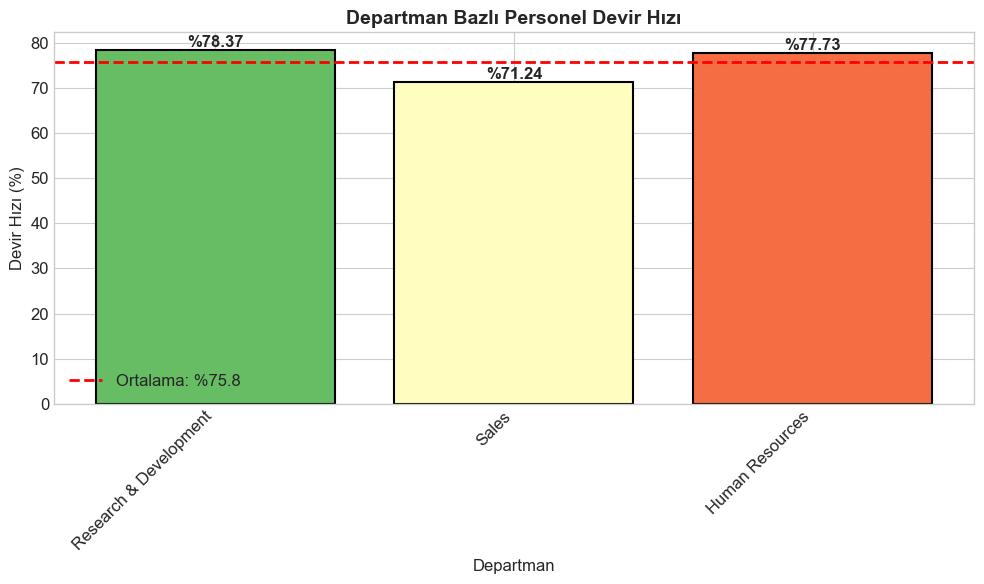

📁 Grafik kaydedildi: outputs/08_turnover_by_department.png


In [16]:
# Departman devir hızı görselleştirme
plt.figure(figsize=(10, 6))

departments = list(dept_turnover.keys())
rates = list(dept_turnover.values())
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(departments)))

bars = plt.bar(departments, rates, color=colors, edgecolor='black', linewidth=1.5)

# Değerleri bar üzerine yaz
for bar, rate in zip(bars, rates):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'%{rate}', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title('Departman Bazlı Personel Devir Hızı', fontsize=14, fontweight='bold')
plt.xlabel('Departman')
plt.ylabel('Devir Hızı (%)')
plt.xticks(rotation=45, ha='right')

# Ortalama çizgisi
avg_turnover = np.mean(rates)
plt.axhline(y=avg_turnover, color='red', linestyle='--', linewidth=2, label=f'Ortalama: %{avg_turnover:.1f}')
plt.legend()

plt.tight_layout()
plt.savefig('../outputs/08_turnover_by_department.png', dpi=300, bbox_inches='tight')
plt.show()
print("📁 Grafik kaydedildi: outputs/08_turnover_by_department.png")

---
## 4. Makine Öğrenmesi: Logistic Regression 🤖

Çalışan ayrılmasını tahmin etmek için Lojistik Regresyon modeli oluşturacağız.

### 4.1 Veri Hazırlığı

In [17]:
# Veri setinin kopyasını oluştur
df_ml = df.copy()

# Hedef değişkeni dönüştür
df_ml['Attrition'] = (df_ml['Attrition'] == 'Yes').astype(int)

# Kategorik değişkenleri belirle
categorical_cols = ['Gender', 'MaritalStatus', 'EducationField', 'Department', 
                    'JobRole', 'BusinessTravel', 'OverTime']

# Label Encoding uygula
le = LabelEncoder()
for col in categorical_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

print("✅ Kategorik değişkenler sayısala dönüştürüldü!")
print(f"\n📋 Dönüştürülen sütunlar: {categorical_cols}")

✅ Kategorik değişkenler sayısala dönüştürüldü!

📋 Dönüştürülen sütunlar: ['Gender', 'MaritalStatus', 'EducationField', 'Department', 'JobRole', 'BusinessTravel', 'OverTime']


In [18]:
# Özellik ve hedef değişkenleri ayır
X = df_ml.drop(['EmployeeID', 'Attrition'], axis=1)
y = df_ml['Attrition']

print(f"📊 Özellik boyutu: {X.shape}")
print(f"🎯 Hedef değişken dağılımı:")
print(y.value_counts())

📊 Özellik boyutu: (1470, 27)
🎯 Hedef değişken dağılımı:
Attrition
1    810
0    660
Name: count, dtype: int64


In [19]:
# Eğitim ve test verisi ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42, stratify=y)

print(f"📊 Eğitim seti boyutu: {X_train.shape[0]} satır")
print(f"📊 Test seti boyutu: {X_test.shape[0]} satır")

📊 Eğitim seti boyutu: 1176 satır
📊 Test seti boyutu: 294 satır


In [20]:
# Özellik ölçeklendirme
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Özellik ölçeklendirme tamamlandı!")

✅ Özellik ölçeklendirme tamamlandı!


### 4.2 Model Eğitimi

In [21]:
# Logistic Regression modeli oluştur ve eğit
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

print("✅ Logistic Regression modeli eğitildi!")

✅ Logistic Regression modeli eğitildi!


### 4.3 Model Değerlendirme

In [22]:
# Tahmin yap
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# Doğruluk skoru
accuracy = accuracy_score(y_test, y_pred)

print("="*60)
print("📊 MODEL PERFORMANSI")
print("="*60)
print(f"\n✅ Doğruluk (Accuracy): %{accuracy*100:.2f}")

📊 MODEL PERFORMANSI

✅ Doğruluk (Accuracy): %80.61


In [23]:
# Classification Report
print("\n📋 Sınıflandırma Raporu:")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Kalan', 'Ayrılan']))


📋 Sınıflandırma Raporu:
              precision    recall  f1-score   support

       Kalan       0.78      0.79      0.78       132
     Ayrılan       0.83      0.82      0.82       162

    accuracy                           0.81       294
   macro avg       0.80      0.80      0.80       294
weighted avg       0.81      0.81      0.81       294



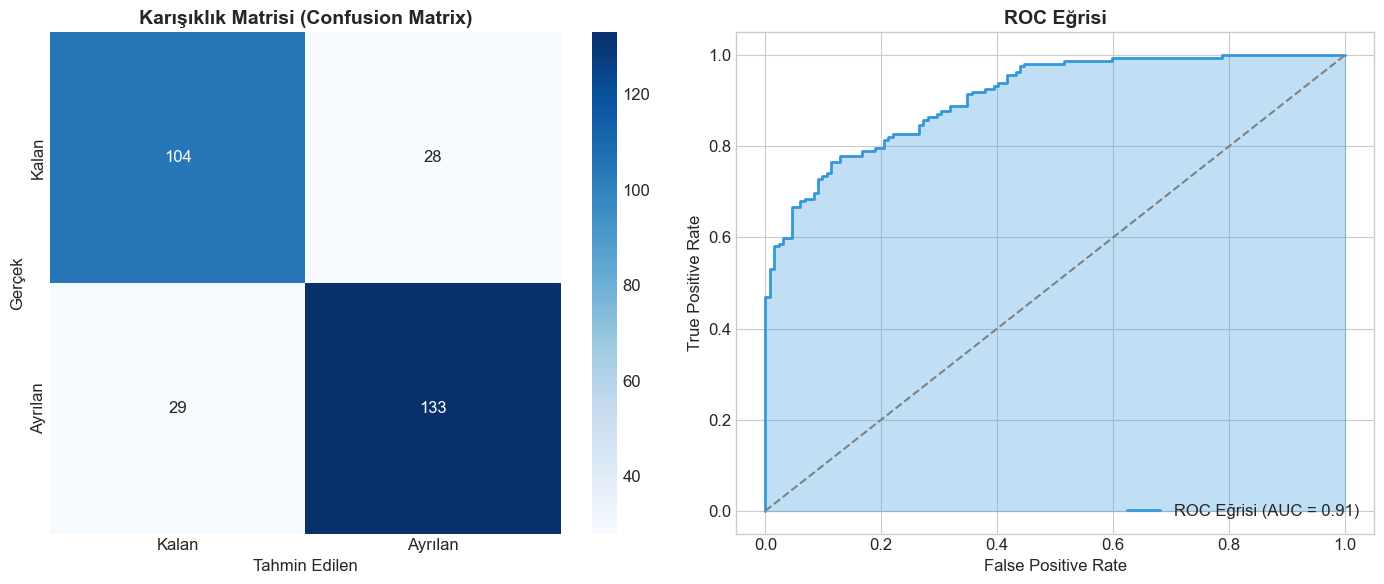

📁 Grafik kaydedildi: outputs/09_model_evaluation.png


In [24]:
# Confusion Matrix görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Kalan', 'Ayrılan'], yticklabels=['Kalan', 'Ayrılan'])
axes[0].set_title('Karışıklık Matrisi (Confusion Matrix)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tahmin Edilen')
axes[0].set_ylabel('Gerçek')

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='#3498db', lw=2, label=f'ROC Eğrisi (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].fill_between(fpr, tpr, alpha=0.3, color='#3498db')
axes[1].set_title('ROC Eğrisi', fontsize=14, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('../outputs/09_model_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()
print("📁 Grafik kaydedildi: outputs/09_model_evaluation.png")

### 4.4 Özellik Önem Sıralaması (Feature Importance)

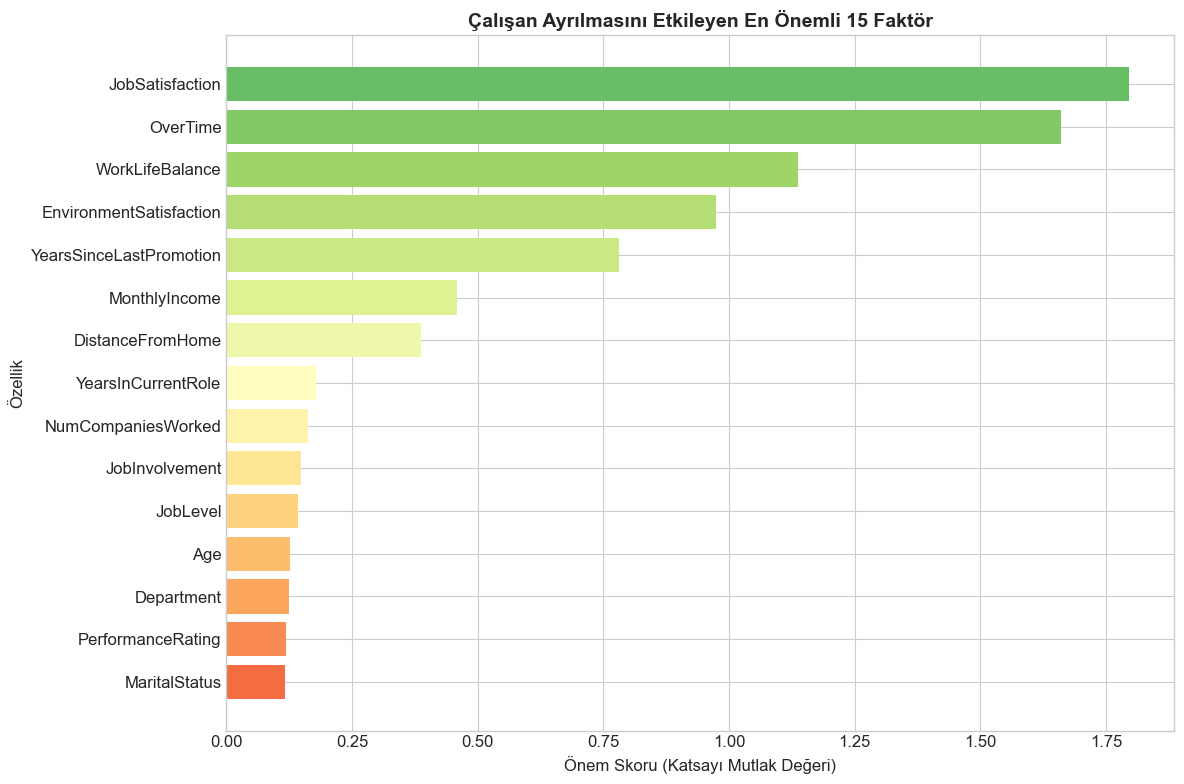

📁 Grafik kaydedildi: outputs/10_feature_importance.png


In [25]:
# Özellik önem sıralaması (Logistic Regression katsayıları)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': np.abs(model.coef_[0])
}).sort_values('Importance', ascending=False)

# En önemli 15 özelliği göster
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)

colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(top_features)))
bars = plt.barh(top_features['Feature'], top_features['Importance'], color=colors)

plt.xlabel('Önem Skoru (Katsayı Mutlak Değeri)')
plt.ylabel('Özellik')
plt.title('Çalışan Ayrılmasını Etkileyen En Önemli 15 Faktör', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/10_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("📁 Grafik kaydedildi: outputs/10_feature_importance.png")

In [26]:
# En önemli özellikleri tablo olarak göster
print("\n" + "="*60)
print("📊 ÇALIŞAN AYRILMASINI ETKİLEYEN EN ÖNEMLİ FAKTÖRLER")
print("="*60)
print("\n🔝 İlk 10 Önemli Özellik:")
print(feature_importance.head(10).to_string(index=False))


📊 ÇALIŞAN AYRILMASINI ETKİLEYEN EN ÖNEMLİ FAKTÖRLER

🔝 İlk 10 Önemli Özellik:
                Feature  Importance
        JobSatisfaction    1.795186
               OverTime    1.659628
        WorkLifeBalance    1.136688
EnvironmentSatisfaction    0.974413
YearsSinceLastPromotion    0.780517
          MonthlyIncome    0.457778
       DistanceFromHome    0.387540
     YearsInCurrentRole    0.178645
     NumCompaniesWorked    0.161731
         JobInvolvement    0.148175


---
## 5. Sonuçlar ve İK Önerileri 📝

In [27]:
# Özet rapor
print("\n" + "="*70)
print("                    📋 ANALİZ ÖZET RAPORU                    ")
print("="*70)

print("\n🎯 TEMEL BULGULAR:")
print("-"*70)
print(f"  • Toplam çalışan sayısı: {len(df)}")
print(f"  • Ayrılan çalışan sayısı: {(df['Attrition'] == 'Yes').sum()} (%{(df['Attrition'] == 'Yes').mean()*100:.1f})")
print(f"  • Genel personel devir hızı: %{turnover}")

print("\n📊 MODEL PERFORMANSI:")
print("-"*70)
print(f"  • Model: Logistic Regression")
print(f"  • Doğruluk (Accuracy): %{accuracy*100:.2f}")
print(f"  • AUC Skoru: {roc_auc:.2f}")

print("\n🔑 EN ETKİLİ FAKTÖRLER:")
print("-"*70)
for i, row in feature_importance.head(5).iterrows():
    print(f"  {i+1}. {row['Feature']}: {row['Importance']:.3f}")

print("\n" + "="*70)


                    📋 ANALİZ ÖZET RAPORU                    

🎯 TEMEL BULGULAR:
----------------------------------------------------------------------
  • Toplam çalışan sayısı: 1470
  • Ayrılan çalışan sayısı: 810 (%55.1)
  • Genel personel devir hızı: %76.06

📊 MODEL PERFORMANSI:
----------------------------------------------------------------------
  • Model: Logistic Regression
  • Doğruluk (Accuracy): %80.61
  • AUC Skoru: 0.91

🔑 EN ETKİLİ FAKTÖRLER:
----------------------------------------------------------------------
  23. JobSatisfaction: 1.795
  21. OverTime: 1.660
  25. WorkLifeBalance: 1.137
  22. EnvironmentSatisfaction: 0.974
  11. YearsSinceLastPromotion: 0.781



In [28]:
# İK Stratejisi Önerileri
print("\n" + "="*70)
print("                    💡 İK STRATEJİSİ ÖNERİLERİ                    ")
print("="*70)

recommendations = """
📌 1. FAZLA MESAİ YÖNETİMİ:
   - Fazla mesai yapan çalışanların ayrılma oranı daha yüksek
   - İş yükü dengelemesi ve esnek çalışma modelleri değerlendirilmeli
   - Fazla mesai için adil tazminat politikaları oluşturulmalı

📌 2. ÜCRET VE TERFI POLİTİKALARI:
   - Düşük maaşlı çalışanlarda ayrılma riski daha yüksek
   - Piyasa rekabetine uygun maaş güncellemeleri yapılmalı
   - Terfi süreçleri şeffaf ve performansa dayalı olmalı

📌 3. ÇALIŞAN MEMNUNİYETİ:
   - İş memnuniyeti düşük çalışanlara özel dikkat gösterilmeli
   - Düzenli çalışan memnuniyet anketleri yapılmalı
   - Geri bildirim mekanizmaları güçlendirilmeli

📌 4. İŞ-YAŞAM DENGESİ:
   - Work-life balance skorları takip edilmeli
   - Uzaktan/hibrit çalışma seçenekleri değerlendirilmeli
   - Çalışan sağlık ve wellness programları oluşturulmalı

📌 5. YENİ ÇALIŞAN UYUM SÜRECİ:
   - İlk 2 yıldaki ayrılma oranları yüksek
   - Güçlü onboarding programları oluşturulmalı
   - Mentor-mentee sistemleri hayata geçirilmeli

📌 6. DEPARTMAN BAZLI MÜDAHALELER:
   - Yüksek devir hızına sahip departmanlara özel çözümler
   - Departman yöneticileri ile düzenli değerlendirme toplantıları
   - Departman içi kariyer gelişim fırsatları
"""
print(recommendations)


                    💡 İK STRATEJİSİ ÖNERİLERİ                    

📌 1. FAZLA MESAİ YÖNETİMİ:
   - Fazla mesai yapan çalışanların ayrılma oranı daha yüksek
   - İş yükü dengelemesi ve esnek çalışma modelleri değerlendirilmeli
   - Fazla mesai için adil tazminat politikaları oluşturulmalı

📌 2. ÜCRET VE TERFI POLİTİKALARI:
   - Düşük maaşlı çalışanlarda ayrılma riski daha yüksek
   - Piyasa rekabetine uygun maaş güncellemeleri yapılmalı
   - Terfi süreçleri şeffaf ve performansa dayalı olmalı

📌 3. ÇALIŞAN MEMNUNİYETİ:
   - İş memnuniyeti düşük çalışanlara özel dikkat gösterilmeli
   - Düzenli çalışan memnuniyet anketleri yapılmalı
   - Geri bildirim mekanizmaları güçlendirilmeli

📌 4. İŞ-YAŞAM DENGESİ:
   - Work-life balance skorları takip edilmeli
   - Uzaktan/hibrit çalışma seçenekleri değerlendirilmeli
   - Çalışan sağlık ve wellness programları oluşturulmalı

📌 5. YENİ ÇALIŞAN UYUM SÜRECİ:
   - İlk 2 yıldaki ayrılma oranları yüksek
   - Güçlü onboarding programları oluşturulmalı
 

---
## 📁 Oluşturulan Görsel Dosyaları

Tüm grafikler `outputs/` klasörüne kaydedilmiştir:

1. `01_attrition_distribution.png` - Ayrılma dağılımı
2. `02_department_analysis.png` - Departman bazlı analiz
3. `03_salary_analysis.png` - Maaş analizi
4. `04_satisfaction_analysis.png` - Memnuniyet analizi
5. `05_age_tenure_analysis.png` - Yaş ve çalışma süresi analizi
6. `06_overtime_analysis.png` - Fazla mesai analizi
7. `07_correlation_matrix.png` - Korelasyon matrisi
8. `08_turnover_by_department.png` - Departman bazlı devir hızı
9. `09_model_evaluation.png` - Model değerlendirme
10. `10_feature_importance.png` - Özellik önem sıralaması

In [29]:
print("\n" + "="*70)
print("           ✅ ANALİZ BAŞARIYLA TAMAMLANDI!           ")
print("="*70)
print("\n📂 Tüm grafikler 'outputs/' klasörüne kaydedildi.")
print("📊 Bu analiz, İK stratejilerinin veriye dayalı olarak geliştirilmesine")
print("   katkı sağlayacak önemli içgörüler sunmaktadır.")
print("\n" + "="*70)


           ✅ ANALİZ BAŞARIYLA TAMAMLANDI!           

📂 Tüm grafikler 'outputs/' klasörüne kaydedildi.
📊 Bu analiz, İK stratejilerinin veriye dayalı olarak geliştirilmesine
   katkı sağlayacak önemli içgörüler sunmaktadır.

